# Analisis Dataset EPA-HTTP (Granularitas Detik)
Notebook ini memproses log akses ASCII **EPA-HTTP** (24 jam), mem-parsing data waktu dengan format kustom `[DD:HH:MM:SS]`, mengelompokkan request ke virtual microservices, dan melakukan agregasi ke **Requests Per Second (RPS)** tingkat detik.

Dataset ini merepresentasikan beban kerja web server Environmental Protection Agency (EPA) pada Agustus 1995.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
log_file_path = 'dataset/epa-http.txt'

print("Membaca dan mem-parsing log file EPA-HTTP secara efisien...")
start_time = time.time()
data = []

with open(log_file_path, 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        try:
            parts = line.split('"')
            host = parts[0].split()[0]
            
            # Format kustom: [DD:HH:MM:SS]
            ts_str = parts[0][parts[0].find('[')+1 : parts[0].find(']')]
            day, hour, minute, second = map(int, ts_str.split(':'))
            dt = datetime(1995, 8, day, hour, minute, second)
            
            req_parts = parts[1].split()
            method = req_parts[0]
            filename = req_parts[1]
            
            status_size_parts = parts[2].strip().split()
            status = int(status_size_parts[0])
            size_str = status_size_parts[1]
            size = int(size_str) if size_str.isdigit() else 0
            
            # Ambil ekstensi file
            ext = filename.split('.')[-1].split('?')[0].lower() if '.' in filename else 'no_ext'
            
            data.append((dt, host, method, ext, status, size))
        except Exception:
            continue

df = pd.DataFrame(data, columns=['datetime', 'host', 'method', 'extension', 'status', 'size_bytes'])
df['host'] = df['host'].astype('category')
df['method'] = df['method'].astype('category')
df['extension'] = df['extension'].astype('category')
df['status'] = df['status'].astype('uint16')
df['size_bytes'] = df['size_bytes'].astype('uint32')

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

print(f"Total baris log: {len(df)} (diproses dalam {time.time() - start_time:.2f} detik)")
df.head()


Membaca dan mem-parsing log file EPA-HTTP secara efisien...


Total baris log: 47721 (diproses dalam 0.58 detik)


,host,method,extension,status,size_bytes
datetime,,,,,
1995-08-29 23:53:25,141.243.1.172,GET,html,200,1497
1995-08-29 23:53:36,query2.lycos.cs.cmu.edu,GET,html,200,1325
1995-08-29 23:53:53,tanuki.twics.com,GET,html,200,1014
1995-08-29 23:54:15,wpbfl2-45.gate.net,GET,no_ext,200,4889
1995-08-29 23:54:16,wpbfl2-45.gate.net,GET,gif,200,2624


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 47721 entries, 1995-08-29 23:53:25 to 1995-08-30 23:53:07
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   host        47721 non-null  category
 1   method      47721 non-null  category
 2   extension   47721 non-null  category
 3   status      47721 non-null  uint16  
 4   size_bytes  47721 non-null  uint32  
dtypes: category(3), uint16(1), uint32(1)
memory usage: 907.8 KB


In [4]:
# Pemetaan ke virtual microservices berdasarkan ekstensi file dan method
# Content_Service -> html, htm, txt, pdf, no_ext
# Media_Service -> gif, jpg, jpeg, xbm
# DynamicAPI_Service -> POST method (Dynamic backend)

html_exts = {'html', 'htm', 'txt', 'pdf', 'no_ext', 'gov'}
image_exts = {'gif', 'jpg', 'jpeg', 'xbm'}

df['service'] = 'Others'
df.loc[df['extension'].isin(html_exts), 'service'] = 'Content_Service'
df.loc[df['extension'].isin(image_exts), 'service'] = 'Media_Service'
df.loc[df['method'] == 'POST', 'service'] = 'DynamicAPI_Service'

df['service'] = df['service'].astype('category')
print(df['service'].value_counts())


service
Media_Service         23080
Content_Service       22148
DynamicAPI_Service     1622
Others                  871
Name: count, dtype: int64


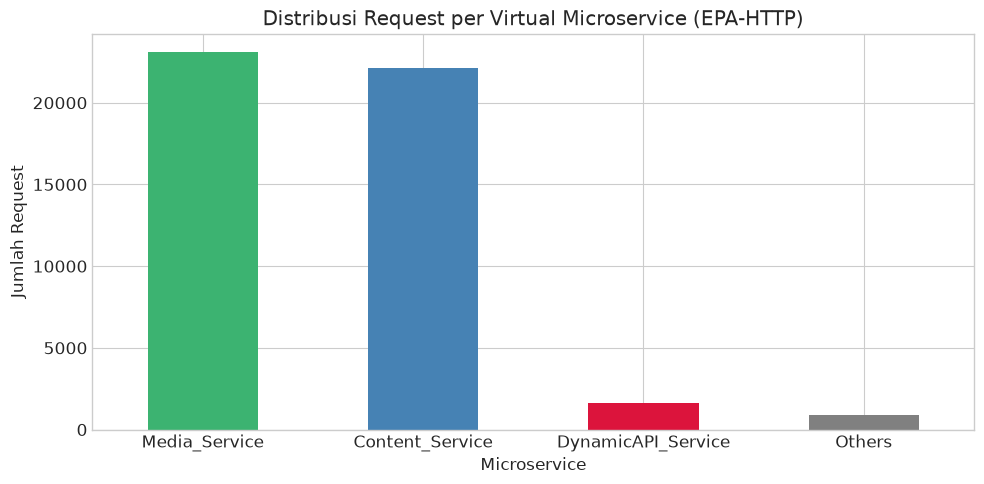

In [5]:
service_counts = df['service'].value_counts()
plt.figure(figsize=(10, 5))
service_counts.plot(kind='bar', color=['mediumseagreen', 'steelblue', 'crimson', 'grey'])
plt.title('Distribusi Request per Virtual Microservice (EPA-HTTP)')
plt.xlabel('Microservice')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Resample ke 1 detik untuk menghitung total RPS (Spans 24 hours, exactly 86400 ticks)
print("Menghitung total RPS per detik...")
# Batasi rentang index ke 24 jam penuh untuk konsistensi
start_str = "1995-08-29 23:53:25"
end_str = "1995-08-30 23:53:07"
idx_full = pd.date_range(start=start_str, end=end_str, freq='s')

total_rps = df.resample('1s').size().reindex(idx_full, fill_value=0)

# Hitung RPS untuk masing-masing virtual microservice
print("Menghitung RPS per-layanan...")
services = df['service'].cat.categories
rps_services = {}

for svc in services:
    svc_df = df[df['service'] == svc]
    rps_services[svc] = svc_df.resample('1s').size().reindex(idx_full, fill_value=0)

# Gabungkan ke satu DataFrame
rps_df = pd.DataFrame(rps_services)
rps_df['total_rps'] = total_rps
rps_df.head()


Menghitung total RPS per detik...
Menghitung RPS per-layanan...


,Content_Service,DynamicAPI_Service,Media_Service,Others,total_rps
1995-08-29 23:53:25,1,0,0,0,1
1995-08-29 23:53:26,0,0,0,0,0
1995-08-29 23:53:27,0,0,0,0,0
1995-08-29 23:53:28,0,0,0,0,0
1995-08-29 23:53:29,0,0,0,0,0


In [7]:
# Statistik Deskriptif RPS
stats = rps_df.describe()
print("Statistik Deskriptif RPS per-detik:")
print(stats.loc[['min', 'mean', 'max']])


Statistik Deskriptif RPS per-detik:
      Content_Service  DynamicAPI_Service  Media_Service    Others  total_rps
min          0.000000            0.000000       0.000000  0.000000   0.000000
mean         0.256393            0.018777       0.267182  0.010083   0.552435
max          8.000000            3.000000      12.000000  2.000000  13.000000


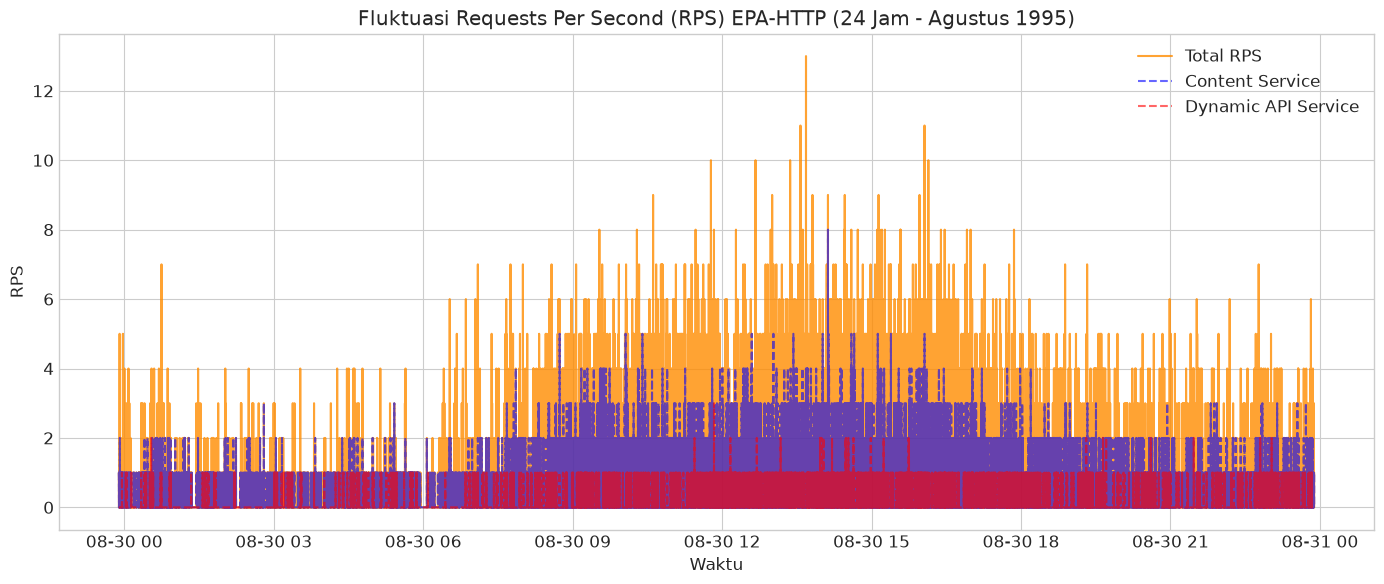

In [8]:
# Plot runtun waktu total RPS
plt.figure(figsize=(14, 6))
plt.plot(rps_df.index, rps_df['total_rps'], label='Total RPS', color='darkorange', alpha=0.8)
plt.plot(rps_df.index, rps_df['Content_Service'], label='Content Service', color='blue', alpha=0.6, linestyle='--')
plt.plot(rps_df.index, rps_df['DynamicAPI_Service'], label='Dynamic API Service', color='red', alpha=0.6, linestyle='--')

plt.title('Fluktuasi Requests Per Second (RPS) EPA-HTTP (24 Jam - Agustus 1995)')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


Trafik puncak terjadi pada: 1995-08-30 13:41:01 dengan 13 RPS


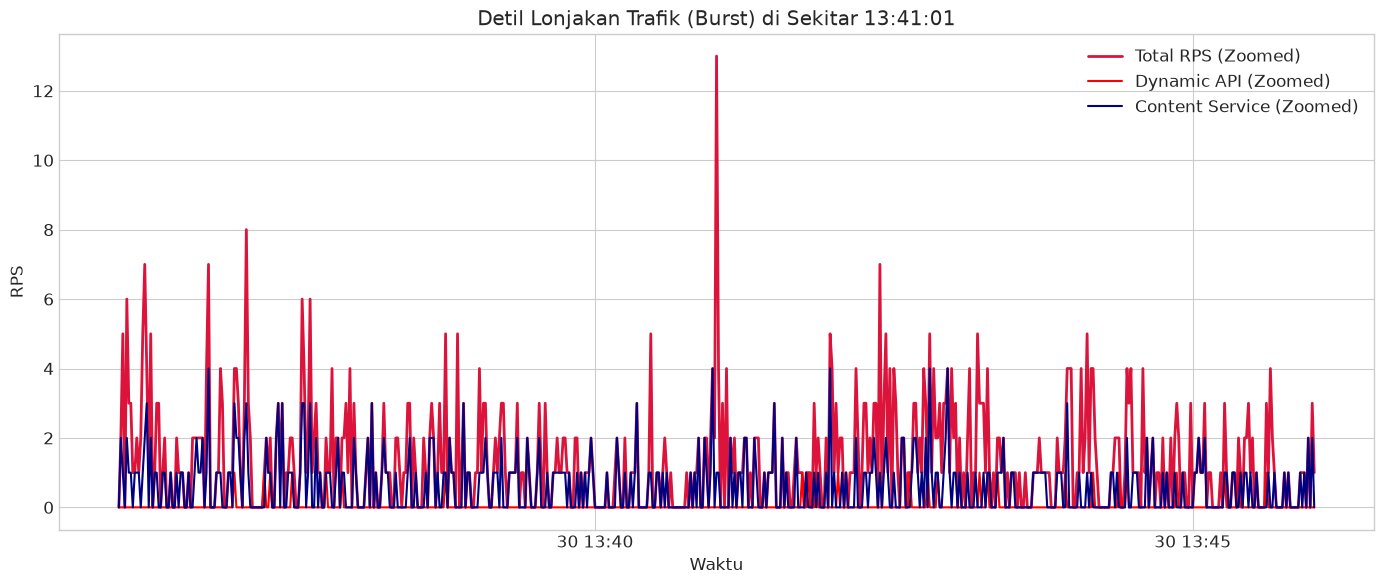

In [9]:
# Cari timestamp di mana terjadi lonjakan (peak)
peak_time = rps_df['total_rps'].idxmax()
print(f"Trafik puncak terjadi pada: {peak_time} dengan {rps_df['total_rps'].max()} RPS")

# Zoom ke area sekitar peak (+/- 5 menit)
zoom_start = peak_time - pd.Timedelta(minutes=5)
zoom_end = peak_time + pd.Timedelta(minutes=5)
zoomed_df = rps_df.loc[zoom_start:zoom_end]

plt.figure(figsize=(14, 6))
plt.plot(zoomed_df.index, zoomed_df['total_rps'], label='Total RPS (Zoomed)', color='crimson', linewidth=2)
plt.plot(zoomed_df.index, zoomed_df['DynamicAPI_Service'], label='Dynamic API (Zoomed)', color='red')
plt.plot(zoomed_df.index, zoomed_df['Content_Service'], label='Content Service (Zoomed)', color='navy')

plt.title(f'Detil Lonjakan Trafik (Burst) di Sekitar {peak_time:%H:%M:%S}')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Simpan hasil agregasi per-detik ke CSV
output_csv_path = 'dataset/aggregated_epa_rps.csv'
rps_df.to_csv(output_csv_path)
print(f"Dataset hasil agregasi per-detik berhasil disimpan ke: {output_csv_path}")


Dataset hasil agregasi per-detik berhasil disimpan ke: dataset/aggregated_epa_rps.csv


## Kesimpulan Skenario Autoscaling
Dataset **EPA-HTTP** merepresentasikan beban kerja web server pemerintah federal Amerika Serikat pada pertengahan 90-an yang stabil namun memiliki lonjakan harian reguler yang khas.